# 2. Deep Learning Baselines Benchmarking: LSTM, RNN, Transformer

Notebook này huấn luyện các baseline deep learning trên IBM HR Analytics để benchmark công bằng với BiTCN:

- **LSTM** xem feature vector như chuỗi 43 bước thời gian, mỗi bước có 1 channel
- **RNN** làm recurrent baseline đơn giản hơn LSTM
- **Transformer Encoder** làm attention-based sequence baseline
- **Stratified 5-Fold Cross Validation**
- **RandomOverSampling chỉ trên training fold**, cùng hướng augmentation oversampling đang tốt nhất cho BiTCN
- Fit scaler chỉ trên train fold, không augment validation fold
- AdamW, scheduler, early stopping, threshold optimization theo F1


## 1. Project Setup


In [1]:
import importlib.util
import os
import random
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
import copy
import json

REQUIRED_PACKAGES = {
    "torch": "torch",
    "sklearn": "scikit-learn",
    "imblearn": "imbalanced-learn",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
}
missing_packages = [
    pip_name for import_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]
if missing_packages:
    print("Missing packages:", ", ".join(missing_packages))
    print("Install in this notebook environment with:")
    print("%pip install " + " ".join(missing_packages))
    raise ImportError("Install the missing packages above, then restart the kernel and rerun this notebook.")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed" / "IBM_Cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/processed/IBM_Cleaned.csv")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "IBM_Cleaned.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "baselines_benchmarking"
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"

for path in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, LOG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

@dataclass
class Config:
    seed: int = 42
    n_splits: int = 5
    target_col: str = "Attrition"
    augmentation: str = "RandomOverSampling"
    batch_size: int = 32
    epochs: int = 160
    patience: int = 28
    lr: float = 7e-4
    weight_decay: float = 5e-5
    dropout: float = 0.40
    threshold_metric: str = "f1"
    num_workers: int = 0
    use_amp: bool = True
    lstm_hidden_dim: int = 64
    lstm_num_layers: int = 2
    rnn_hidden_dim: int = 64
    rnn_num_layers: int = 2
    transformer_d_model: int = 64
    transformer_nhead: int = 4
    transformer_num_layers: int = 2
    transformer_dim_feedforward: int = 128

CFG = Config()

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

seed_everything(CFG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
AMP_ENABLED = CFG.use_amp and DEVICE.type == "cuda"

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"Augmentation for both baselines: {CFG.augmentation}")
print(json.dumps(asdict(CFG), indent=2))

with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)


f:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN
Device: cpu
Augmentation for both baselines: RandomOverSampling
{
  "seed": 42,
  "n_splits": 5,
  "target_col": "Attrition",
  "augmentation": "RandomOverSampling",
  "batch_size": 32,
  "epochs": 160,
  "patience": 28,
  "lr": 0.0007,
  "weight_decay": 5e-05,
  "dropout": 0.4,
  "threshold_metric": "f1",
  "num_workers": 0,
  "use_amp": true,
  "lstm_hidden_dim": 64,
  "lstm_num_layers": 2,
  "rnn_hidden_dim": 64,
  "rnn_num_layers": 2,
  "transformer_d_model": 64,
  "transformer_nhead": 4,
  "transformer_num_layers": 2,
  "transformer_dim_feedforward": 128
}


## 2. Load Dataset


In [2]:
df = pd.read_csv(DATA_PATH)

if CFG.target_col not in df.columns:
    raise ValueError(f"Expected target column '{CFG.target_col}', found: {list(df.columns)}")

print("Dataset shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicated rows:", int(df.duplicated().sum()))
print("\nClass distribution:")
print(df[CFG.target_col].value_counts().sort_index())
display(df.head())


Dataset shape: (1470, 44)
Missing values: 0
Duplicated rows: 0

Class distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.547619,1,0.5,0.715820,0.000000,0.25,0.333333,0.0,0.914286,0.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.738095,0,1.0,0.126700,0.250000,0.00,0.666667,1.0,0.442857,0.333333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.452381,1,0.5,0.909807,0.035714,0.25,1.000000,1.0,0.885714,0.333333,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.357143,0,1.0,0.923407,0.071429,0.75,1.000000,0.0,0.371429,0.666667,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.214286,0,0.5,0.350036,0.035714,0.00,0.000000,1.0,0.142857,0.666667,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 3. Feature / Target Split


In [3]:
X_df = df.drop(columns=[CFG.target_col]).copy()
y = df[CFG.target_col].astype(int).to_numpy()
feature_names = X_df.columns.tolist()
X_raw = X_df.astype("float32").to_numpy()
n_features = X_raw.shape[1]

print(f"Samples: {X_raw.shape[0]}")
print(f"Features: {n_features}")


Samples: 1470
Features: 43


## 4. Metrics, Dataset, and Oversampling Helpers


In [4]:
def find_best_threshold(y_true: np.ndarray, y_prob: np.ndarray, metric: str = "f1"):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5, 0.0
    precision = precision[:-1]
    recall = recall[:-1]
    scores = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = int(np.nanargmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])

def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "threshold": threshold,
    }

def summarize_metrics(rows: list[dict]) -> pd.DataFrame:
    df_metrics = pd.DataFrame(rows)
    metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold", "best_epoch"]
    summary = df_metrics[metric_cols].agg(["mean", "std"]).T
    summary["mean_std"] = summary.apply(lambda r: f"{r['mean']:.4f} +/- {r['std']:.4f}", axis=1)
    return summary

def apply_random_oversampling(X_train: np.ndarray, y_train: np.ndarray, seed: int):
    sampler = RandomOverSampler(random_state=seed)
    X_aug, y_aug = sampler.fit_resample(X_train, y_train)
    print("Before oversampling:", dict(zip(*np.unique(y_train, return_counts=True))))
    print("After oversampling:", dict(zip(*np.unique(y_aug, return_counts=True))))
    return X_aug.astype("float32"), y_aug.astype(int)

def make_lstm_loader(X_2d: np.ndarray, y_1d: np.ndarray, train: bool) -> DataLoader:
    X_seq = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], 1)
    dataset = TensorDataset(
        torch.tensor(X_seq, dtype=torch.float32),
        torch.tensor(y_1d.reshape(-1, 1), dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=CFG.batch_size, shuffle=train,
                      num_workers=CFG.num_workers, pin_memory=PIN_MEMORY)


## 5. Model Definitions


In [5]:
class LSTMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=CFG.lstm_hidden_dim,
            num_layers=CFG.lstm_num_layers,
            batch_first=True,
            dropout=CFG.dropout if CFG.lstm_num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(CFG.lstm_hidden_dim * 2),
            nn.Linear(CFG.lstm_hidden_dim * 2, CFG.lstm_hidden_dim),
            nn.GELU(),
            nn.Dropout(CFG.dropout),
            nn.Linear(CFG.lstm_hidden_dim, 1),
        )

    def forward(self, x):
        output, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]
        max_pool = output.max(dim=1).values
        features = torch.cat([last_hidden, max_pool], dim=1)
        return self.classifier(features)


class RNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=CFG.rnn_hidden_dim,
            num_layers=CFG.rnn_num_layers,
            nonlinearity="tanh",
            batch_first=True,
            dropout=CFG.dropout if CFG.rnn_num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(CFG.rnn_hidden_dim * 2),
            nn.Linear(CFG.rnn_hidden_dim * 2, CFG.rnn_hidden_dim),
            nn.GELU(),
            nn.Dropout(CFG.dropout),
            nn.Linear(CFG.rnn_hidden_dim, 1),
        )

    def forward(self, x):
        output, h_n = self.rnn(x)
        last_hidden = h_n[-1]
        max_pool = output.max(dim=1).values
        features = torch.cat([last_hidden, max_pool], dim=1)
        return self.classifier(features)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class TransformerClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_projection = nn.Linear(1, CFG.transformer_d_model)
        self.position = PositionalEncoding(CFG.transformer_d_model, max_len=n_features)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=CFG.transformer_d_model,
            nhead=CFG.transformer_nhead,
            dim_feedforward=CFG.transformer_dim_feedforward,
            dropout=CFG.dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=CFG.transformer_num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(CFG.transformer_d_model * 2),
            nn.Linear(CFG.transformer_d_model * 2, CFG.transformer_d_model),
            nn.GELU(),
            nn.Dropout(CFG.dropout),
            nn.Linear(CFG.transformer_d_model, 1),
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.position(x)
        encoded = self.encoder(x)
        mean_pool = encoded.mean(dim=1)
        max_pool = encoded.max(dim=1).values
        features = torch.cat([mean_pool, max_pool], dim=1)
        return self.classifier(features)


def make_model(model_name: str):
    if model_name == "LSTM":
        return LSTMClassifier().to(DEVICE)
    if model_name == "RNN":
        return RNNClassifier().to(DEVICE)
    if model_name == "Transformer":
        return TransformerClassifier().to(DEVICE)
    raise ValueError(f"Unknown model: {model_name}")

BENCHMARK_MODELS = ["LSTM", "RNN", "Transformer"]

for name in BENCHMARK_MODELS:
    preview = make_model(name)
    params = sum(p.numel() for p in preview.parameters() if p.requires_grad)
    print(f"{name} trainable parameters: {params:,}")
    del preview


LSTM trainable parameters: 59,009
RNN trainable parameters: 21,185
Transformer trainable parameters: 75,649


## 6. Training Functions


In [6]:
def make_loss(y_train_aug: np.ndarray):
    positives = float(np.sum(y_train_aug == 1))
    negatives = float(np.sum(y_train_aug == 0))
    pos_weight_value = negatives / max(positives, 1.0)
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight), pos_weight_value

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    probs, targets = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits = model(xb)
            loss = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * xb.size(0)
        probs.append(torch.sigmoid(logits.detach()).cpu().numpy().ravel())
        targets.append(yb.detach().cpu().numpy().ravel())

    y_prob = np.concatenate(probs)
    y_true = np.concatenate(targets).astype(int)
    threshold, _ = find_best_threshold(y_true, y_prob, CFG.threshold_metric)
    metrics = compute_metrics(y_true, y_prob, threshold)
    metrics["loss"] = running_loss / len(loader.dataset)
    return metrics

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    probs, targets = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        running_loss += loss.item() * xb.size(0)
        probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
        targets.append(yb.cpu().numpy().ravel())

    y_prob = np.concatenate(probs)
    y_true = np.concatenate(targets).astype(int)
    threshold, threshold_score = find_best_threshold(y_true, y_prob, CFG.threshold_metric)
    metrics = compute_metrics(y_true, y_prob, threshold)
    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["threshold_score"] = threshold_score
    return metrics, y_true, y_prob


## 7. Cross-Validation Training


In [7]:
def save_fold_artifacts(model_name: str, fold: int, y_true: np.ndarray, y_prob: np.ndarray, threshold: float):
    run_name = model_name.lower()
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.8, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Attrition", "Attrition"], yticklabels=["No Attrition", "Attrition"])
    plt.title(f"{model_name} Fold {fold} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{run_name}_fold_{fold}_confusion_matrix.png", dpi=300)
    plt.close()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"ROC-AUC={roc_auc_score(y_true, y_prob):.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} Fold {fold} ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{run_name}_fold_{fold}_roc_curve.png", dpi=300)
    plt.close()

    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision, label=f"PR-AUC={average_precision_score(y_true, y_prob):.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Fold {fold} PR Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{run_name}_fold_{fold}_pr_curve.png", dpi=300)
    plt.close()

    report = classification_report(y_true, y_pred, target_names=["No Attrition", "Attrition"], zero_division=0)
    with open(LOG_DIR / f"{run_name}_fold_{fold}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report)

def run_cv(model_name: str):
    skf = StratifiedKFold(n_splits=CFG.n_splits, shuffle=True, random_state=CFG.seed)
    fold_results = []
    histories = {}
    oof_probs = np.zeros(len(y), dtype=np.float32)
    oof_thresholds = np.zeros(CFG.n_splits, dtype=np.float32)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y), start=1):
        print(f"\n{'=' * 18} {model_name} Fold {fold}/{CFG.n_splits} {'=' * 18}")
        seed_everything(CFG.seed + fold)

        X_train_raw, X_val_raw = X_raw[train_idx], X_raw[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        scaler_preprocess = MinMaxScaler()
        X_train = scaler_preprocess.fit_transform(X_train_raw).astype("float32")
        X_val = scaler_preprocess.transform(X_val_raw).astype("float32")

        X_train_aug, y_train_aug = apply_random_oversampling(X_train, y_train, seed=CFG.seed + fold)

        train_loader = make_lstm_loader(X_train_aug, y_train_aug, train=True)
        val_loader = make_lstm_loader(X_val, y_val, train=False)

        model = make_model(model_name)
        criterion, pos_weight_value = make_loss(y_train_aug)
        optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=6, min_lr=1e-6
        )
        amp_scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

        best_state = None
        best_metrics = None
        best_epoch = 0
        best_f1 = -np.inf
        no_improve = 0
        history = []
        start_time = time.time()

        epoch_iter = tqdm(range(1, CFG.epochs + 1), desc=f"{model_name} fold {fold}", leave=False)
        for epoch in epoch_iter:
            train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, amp_scaler)
            val_metrics, y_val_true, y_val_prob = evaluate(model, val_loader, criterion)
            scheduler.step(val_metrics["f1"])

            history.append({
                "epoch": epoch,
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}": v for k, v in val_metrics.items()},
                "lr": optimizer.param_groups[0]["lr"],
            })
            epoch_iter.set_postfix(
                train_loss=f"{train_metrics['loss']:.4f}",
                val_loss=f"{val_metrics['loss']:.4f}",
                val_f1=f"{val_metrics['f1']:.4f}",
                val_auc=f"{val_metrics['roc_auc']:.4f}",
            )

            if val_metrics["f1"] > best_f1 + 1e-5:
                best_f1 = val_metrics["f1"]
                best_epoch = epoch
                best_state = copy.deepcopy(model.state_dict())
                best_metrics = val_metrics.copy()
                best_y_true = y_val_true.copy()
                best_y_prob = y_val_prob.copy()
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= CFG.patience:
                print(f"Early stopping at epoch {epoch}; best epoch = {best_epoch}, best F1 = {best_f1:.4f}")
                break

        if best_state is None:
            raise RuntimeError(f"No best state captured for {model_name} fold {fold}.")

        run_name = model_name.lower()
        checkpoint_path = MODEL_DIR / f"{run_name}_randomoversampling_best_model_fold_{fold}.pth"
        torch.save({
            "model_name": model_name,
            "fold": fold,
            "augmentation": CFG.augmentation,
            "model_state_dict": best_state,
            "config": asdict(CFG),
            "feature_names": feature_names,
            "best_epoch": best_epoch,
            "best_metrics": best_metrics,
            "pos_weight": pos_weight_value,
        }, checkpoint_path)

        history_df = pd.DataFrame(history)
        history_df.to_csv(LOG_DIR / f"{run_name}_fold_{fold}_history.csv", index=False)
        histories[fold] = history_df

        best_metrics["model"] = model_name
        best_metrics["fold"] = fold
        best_metrics["best_epoch"] = best_epoch
        best_metrics["augmentation"] = CFG.augmentation
        best_metrics["train_size"] = len(train_idx)
        best_metrics["train_size_after_aug"] = len(y_train_aug)
        best_metrics["val_size"] = len(val_idx)
        best_metrics["seconds"] = time.time() - start_time
        fold_results.append(best_metrics)

        oof_probs[val_idx] = best_y_prob
        oof_thresholds[fold - 1] = best_metrics["threshold"]
        save_fold_artifacts(model_name, fold, best_y_true, best_y_prob, best_metrics["threshold"])

        print(
            f"{model_name} fold {fold} | best epoch {best_epoch} | "
            f"Acc={best_metrics['accuracy']:.4f}, P={best_metrics['precision']:.4f}, "
            f"R={best_metrics['recall']:.4f}, F1={best_metrics['f1']:.4f}, "
            f"AUC={best_metrics['roc_auc']:.4f}, threshold={best_metrics['threshold']:.3f}"
        )

    global_threshold, global_score = find_best_threshold(y, oof_probs, CFG.threshold_metric)
    oof_metrics = compute_metrics(y, oof_probs, global_threshold)
    oof_metrics["model"] = model_name
    oof_metrics["augmentation"] = CFG.augmentation
    oof_metrics["threshold_score"] = global_score
    oof_metrics["mean_fold_threshold"] = float(np.mean(oof_thresholds))

    fold_results_df = pd.DataFrame(fold_results).sort_values("fold")
    summary_df = summarize_metrics(fold_results)
    fold_results_df.to_csv(OUTPUT_DIR / f"{model_name.lower()}_fold_results.csv", index=False)
    summary_df.to_csv(OUTPUT_DIR / f"{model_name.lower()}_metrics_summary.csv")

    with open(OUTPUT_DIR / f"{model_name.lower()}_oof_metrics.json", "w", encoding="utf-8") as f:
        json.dump(oof_metrics, f, indent=2)

    return {
        "model": model_name,
        "fold_results_df": fold_results_df,
        "summary_df": summary_df,
        "histories": histories,
        "oof_probs": oof_probs,
        "oof_metrics": oof_metrics,
    }

benchmark_outputs = {model_name: run_cv(model_name) for model_name in BENCHMARK_MODELS}

baseline_results_df = pd.DataFrame([output["oof_metrics"] for output in benchmark_outputs.values()])
baseline_results_df = baseline_results_df[[
    "model", "augmentation", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold"
]]
baseline_results_df.to_csv(OUTPUT_DIR / "deep_learning_baseline_results.csv", index=False)

display(baseline_results_df)
for model_name, output in benchmark_outputs.items():
    print(f"\n{model_name} fold summary")
    display(output["fold_results_df"])
    display(output["summary_df"])



================== LSTM Fold 1/5 ==================
Before oversampling: {np.int64(0): np.int64(987), np.int64(1): np.int64(189)}
After oversampling: {np.int64(0): np.int64(987), np.int64(1): np.int64(987)}


Early stopping at epoch 45; best epoch = 17, best F1 = 0.4815
LSTM fold 1 | best epoch 17 | Acc=0.8095, P=0.4333, R=0.5417, F1=0.4815, AUC=0.7261, threshold=0.568

================== LSTM Fold 2/5 ==================
Before oversampling: {np.int64(0): np.int64(987), np.int64(1): np.int64(189)}
After oversampling: {np.int64(0): np.int64(987), np.int64(1): np.int64(987)}


Early stopping at epoch 36; best epoch = 8, best F1 = 0.3894
LSTM fold 2 | best epoch 8 | Acc=0.7653, P=0.3385, R=0.4583, F1=0.3894, AUC=0.6238, threshold=0.667

================== LSTM Fold 3/5 ==================
Before oversampling: {np.int64(0): np.int64(986), np.int64(1): np.int64(190)}
After oversampling: {np.int64(0): np.int64(986), np.int64(1): np.int64(986)}


Early stopping at epoch 59; best epoch = 31, best F1 = 0.5111
LSTM fold 3 | best epoch 31 | Acc=0.8503, P=0.5349, R=0.4894, F1=0.5111, AUC=0.7287, threshold=0.656

================== LSTM Fold 4/5 ==================
Before oversampling: {np.int64(0): np.int64(986), np.int64(1): np.int64(190)}
After oversampling: {np.int64(0): np.int64(986), np.int64(1): np.int64(986)}


Early stopping at epoch 29; best epoch = 1, best F1 = 0.3910
LSTM fold 4 | best epoch 1 | Acc=0.7245, P=0.3023, R=0.5532, F1=0.3910, AUC=0.6675, threshold=0.455

================== LSTM Fold 5/5 ==================
Before oversampling: {np.int64(0): np.int64(986), np.int64(1): np.int64(190)}
After oversampling: {np.int64(0): np.int64(986), np.int64(1): np.int64(986)}


...

,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,loss,threshold_score,model,fold,best_epoch,augmentation,train_size,train_size_after_aug,val_size,seconds
0,0.812925,0.447761,0.625000,0.521739,0.783198,0.417461,0.606484,0.552564,0.521739,RNN,1,16,RandomOverSampling,1176,1974,294,35.572683
1,0.826531,0.476190,0.625000,0.540541,0.751355,0.515113,0.555783,0.473067,0.540541,RNN,2,29,RandomOverSampling,1176,1974,294,45.213706
2,0.829932,0.470588,0.510638,0.489796,0.738823,0.418175,0.798167,0.644186,0.489796,RNN,3,43,RandomOverSampling,1176,1972,294,55.161042
3,0.884354,0.658537,0.574468,0.613636,0.821432,0.612045,0.543678,0.361497,0.613636,RNN,4,28,RandomOverSampling,1176,1972,294,43.522577
4,0.806122,0.428571,0.638298,0.512821,0.778965,0.411364,0.582322,0.536031,0.512821,RNN,5,15,RandomOverSampling,1176,1972,294,33.499919


,mean,std,mean_std
accuracy,0.831973,0.030857,0.8320 +/- 0.0309
precision,0.496330,0.092641,0.4963 +/- 0.0926
recall,0.594681,0.052945,0.5947 +/- 0.0529
f1,0.535706,0.047231,0.5357 +/- 0.0472
roc_auc,0.774754,0.032040,0.7748 +/- 0.0320
pr_auc,0.474831,0.088005,0.4748 +/- 0.0880
threshold,0.617287,0.103993,0.6173 +/- 0.1040
best_epoch,26.200000,11.432410,26.2000 +/- 11.4324



Transformer fold summary


,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,loss,threshold_score,model,fold,best_epoch,augmentation,train_size,train_size_after_aug,val_size,seconds
0,0.863946,0.586957,0.562500,0.574468,0.801236,0.531033,0.678716,0.441090,0.574468,Transformer,1,25,RandomOverSampling,1176,1974,294,104.660848
1,0.863946,0.583333,0.583333,0.583333,0.811907,0.597494,0.826096,0.608911,0.583333,Transformer,2,21,RandomOverSampling,1176,1974,294,95.658716
2,0.840136,0.500000,0.638298,0.560748,0.815057,0.548435,0.338712,0.435278,0.560748,Transformer,3,17,RandomOverSampling,1176,1972,294,89.242096
3,0.887755,0.718750,0.489362,0.582278,0.795159,0.586627,0.840895,0.511885,0.582278,Transformer,4,15,RandomOverSampling,1176,1972,294,85.338093
4,0.843537,0.507463,0.723404,0.596491,0.809027,0.580344,0.295373,0.368113,0.596491,Transformer,5,41,RandomOverSampling,1176,1972,294,137.742439


,mean,std,mean_std
accuracy,0.859864,0.019151,0.8599 +/- 0.0192
precision,0.579301,0.087992,0.5793 +/- 0.0880
recall,0.599379,0.087490,0.5994 +/- 0.0875
f1,0.579464,0.013116,0.5795 +/- 0.0131
roc_auc,0.806477,0.008142,0.8065 +/- 0.0081
pr_auc,0.568787,0.027908,0.5688 +/- 0.0279
threshold,0.595958,0.262837,0.5960 +/- 0.2628
best_epoch,23.800000,10.353743,23.8000 +/- 10.3537


## 8. Visualization and BiTCN Comparison


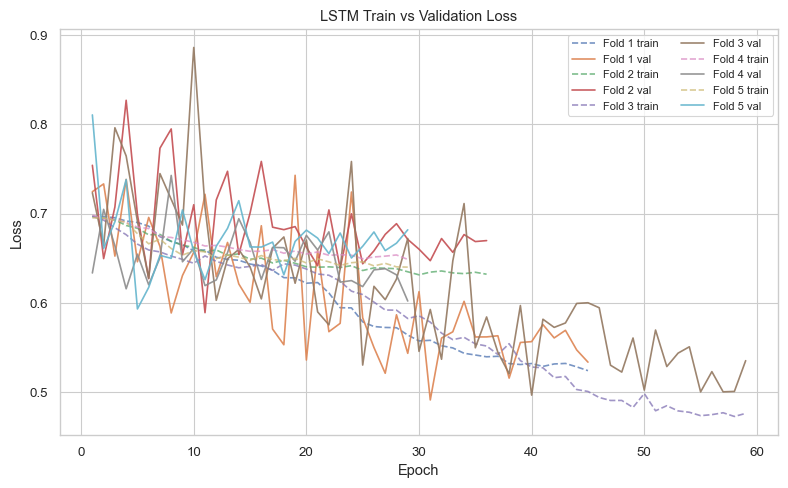

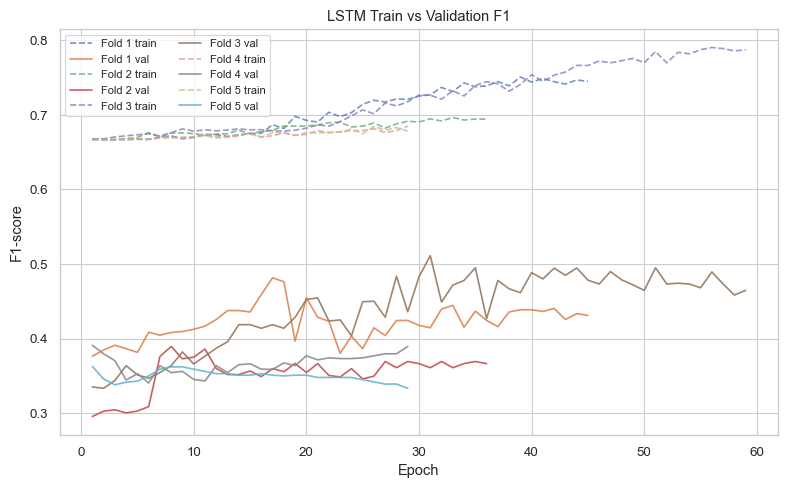

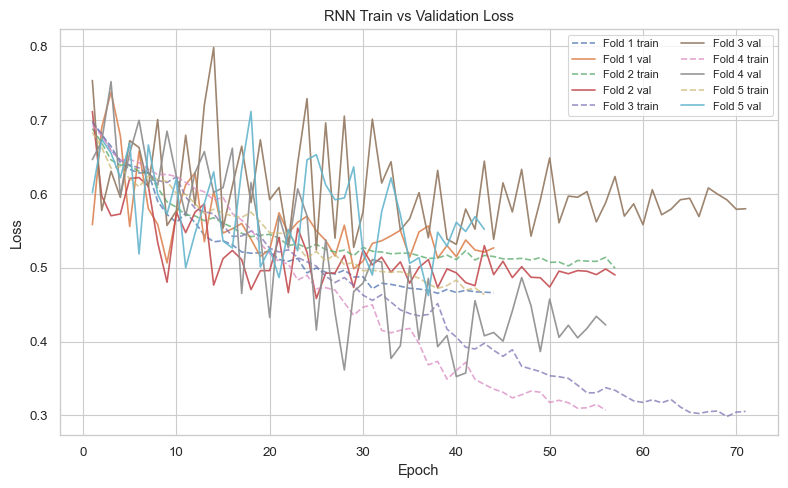

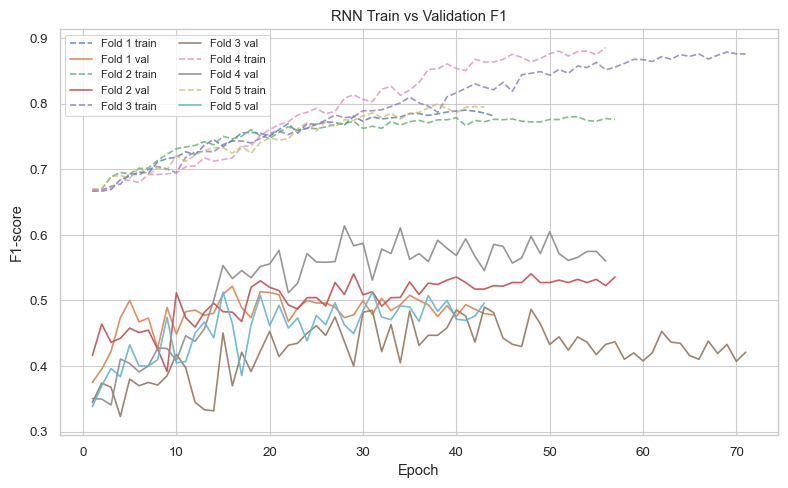

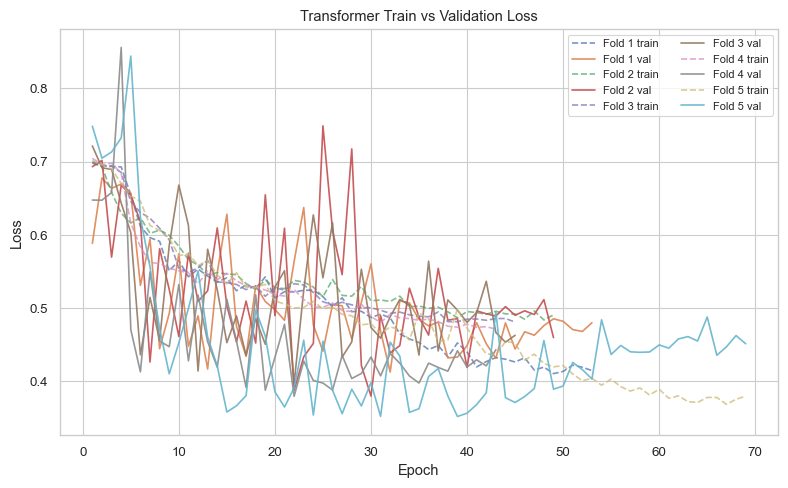

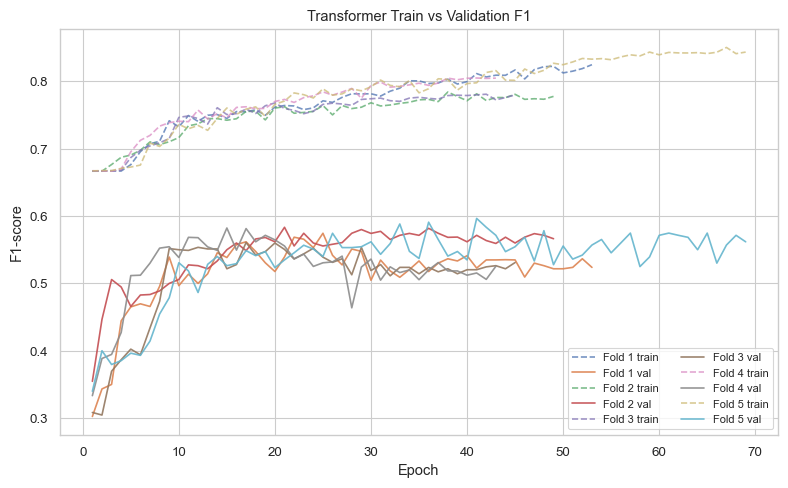

,model,augmentation,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Bi-TCN IBM,NaN,0.843537,0.514056,0.540084,0.526749,0.782288,0.482260
3,Transformer,RandomOverSampling,0.842857,0.512097,0.535865,0.523711,0.794368,0.537181
2,RNN,RandomOverSampling,0.823129,0.461279,0.578059,0.513109,0.766194,0.419180
1,LSTM,RandomOverSampling,0.712925,0.277108,0.485232,0.352761,0.647257,0.308082


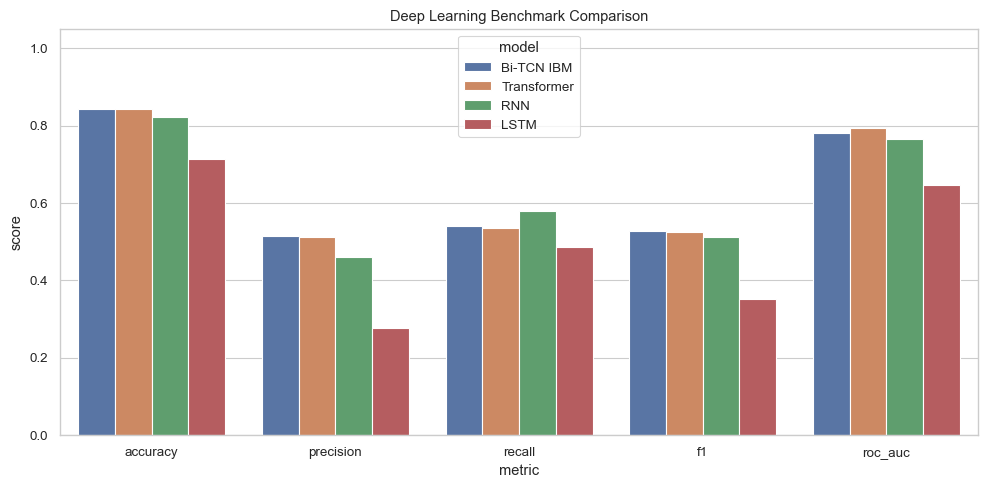

In [8]:
for model_name, output in benchmark_outputs.items():
    histories = output["histories"]
    plt.figure(figsize=(8, 5))
    for fold, hist in histories.items():
        plt.plot(hist["epoch"], hist["train_loss"], linestyle="--", alpha=0.75, label=f"Fold {fold} train")
        plt.plot(hist["epoch"], hist["val_loss"], alpha=0.9, label=f"Fold {fold} val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Train vs Validation Loss")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_name.lower()}_loss_curves_all_folds.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    for fold, hist in histories.items():
        plt.plot(hist["epoch"], hist["train_f1"], linestyle="--", alpha=0.75, label=f"Fold {fold} train")
        plt.plot(hist["epoch"], hist["val_f1"], alpha=0.9, label=f"Fold {fold} val")
    plt.xlabel("Epoch")
    plt.ylabel("F1-score")
    plt.title(f"{model_name} Train vs Validation F1")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_name.lower()}_f1_curves_all_folds.png", dpi=300)
    plt.show()

bitcn_candidates = [
    PROJECT_ROOT / "outputs" / "bitcn_ibm" / "model_comparison.csv",
    PROJECT_ROOT / "outputs" / "bitcn_ibm" / "augmentation_comparison.csv",
    PROJECT_ROOT / "outputs" / "bitcn_ibm" / "oof_metrics.json",
]

comparison_rows = baseline_results_df.copy()
if bitcn_candidates[0].exists():
    bitcn_df = pd.read_csv(bitcn_candidates[0])
    comparison_rows = pd.concat([bitcn_df, comparison_rows], ignore_index=True, sort=False)
elif bitcn_candidates[1].exists():
    bitcn_aug = pd.read_csv(bitcn_candidates[1]).sort_values(["f1", "roc_auc", "recall"], ascending=False).head(1)
    bitcn_aug = bitcn_aug.rename(columns={"augmentation": "augmentation"})
    bitcn_aug["model"] = "BiTCN"
    comparison_rows = pd.concat([bitcn_aug, comparison_rows], ignore_index=True, sort=False)
elif bitcn_candidates[2].exists():
    with open(bitcn_candidates[2], "r", encoding="utf-8") as f:
        bitcn_metrics = json.load(f)
    bitcn_metrics["model"] = "BiTCN"
    comparison_rows = pd.concat([pd.DataFrame([bitcn_metrics]), comparison_rows], ignore_index=True, sort=False)
else:
    print("BiTCN output not found; exporting deep-learning-baselines-only comparison.")

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
available_metric_cols = [c for c in metric_cols if c in comparison_rows.columns]
comparison_rows = comparison_rows.sort_values(["f1", "roc_auc"], ascending=False, na_position="last")
comparison_rows.to_csv(OUTPUT_DIR / "benchmark_comparison_with_bitcn.csv", index=False)
display(comparison_rows[["model", *[c for c in ["augmentation"] if c in comparison_rows.columns], *available_metric_cols]])

plot_df = comparison_rows.dropna(subset=["f1"]).copy()
if not plot_df.empty:
    melted = plot_df.melt(id_vars=["model"], value_vars=[c for c in ["accuracy", "precision", "recall", "f1", "roc_auc"] if c in plot_df.columns],
                          var_name="metric", value_name="score")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=melted, x="metric", y="score", hue="model")
    plt.ylim(0, 1.05)
    plt.title("Deep Learning Benchmark Comparison")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "benchmark_comparison_with_bitcn.png", dpi=300)
    plt.show()


## 9. Output Files


In [9]:
print("Saved artifacts:")
for path in [
    OUTPUT_DIR / "config.json",
    OUTPUT_DIR / "deep_learning_baseline_results.csv",
    OUTPUT_DIR / "benchmark_comparison_with_bitcn.csv",
    OUTPUT_DIR / "lstm_fold_results.csv",
    OUTPUT_DIR / "rnn_fold_results.csv",
    OUTPUT_DIR / "transformer_fold_results.csv",
    OUTPUT_DIR / "lstm_metrics_summary.csv",
    OUTPUT_DIR / "rnn_metrics_summary.csv",
    OUTPUT_DIR / "transformer_metrics_summary.csv",
]:
    print("-", path)

print("\nModel checkpoints:")
for path in sorted(MODEL_DIR.glob("*_randomoversampling_best_model_fold_*.pth")):
    print("-", path)


Saved artifacts:
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\baselines_benchmarking\config.json
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\baselines_benchmarking\deep_learning_baseline_results.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\baselines_benchmarking\benchmark_comparison_with_bitcn.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\baselines_benchmarking\lstm_fold_results.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\baselines_benchmarking\rnn_fold_results.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\baselines_benchmarking\transformer_fold_results.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\baselines_benchmarking\lstm_metrics_summary.csv
- F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\outputs\baselines_benchmarking\rnn_metrics_summary.csv
- F:\ML - DL Projects\Deep Learning Employe